# Bay Area Transit Demand Forecasting — Exploratory Data Analysis

**CS 163 Senior Project · SJSU · Spring 2026 · Dhruv Punit Shah**

This notebook explores the BART origin-destination monthly ridership dataset (2019 + 2022–2023),
joined with Open-Meteo weather and a Bay Area events calendar. It produces 10 diagnostic charts:

| # | Plot |
|---|------|
| 01 | Ridership time series overview (all stations) |
| 02 | Hourly ridership heatmap (station × hour-of-day) |
| 03 | Day-of-week ridership distribution |
| 04 | Sharks game night spike (before/during/after comparison) |
| 05 | Rain vs ridership scatter (nonlinear relationship) |
| 06 | Station ridership ranking (bar chart) |
| 07 | Missing data heatmap (which stations have gaps?) |
| 08 | Event proximity score vs ridership lift (Diridon focus) |
| 09 | Seasonal decomposition (trend + seasonality + residual) |
| 10 | Correlation heatmap (feature vs ridership correlations) |

> **Prerequisites:** Run `python machine_learning_files/merge_pipeline.py` and
> `python Processing/feature_engineering.py` first to build `data/processed/feature_store_enriched.parquet`.


## Setup


In [1]:
from __future__ import annotations
import os
import warnings
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# Walk up from the current working directory to the repo root (identified by
# README.md + configs/model.yaml existing there) instead of a hardcoded,
# author-machine-specific absolute path, so this notebook is runnable from
# any checkout regardless of where Jupyter was launched from.
def _find_repo_root():
    start = Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "configs" / "model.yaml").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the transit-demand-forecasting repo root from "
        f"{start} — run this notebook from within the repo checkout."
    )

os.chdir(_find_repo_root())

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(name)s: %(message)s')
log = logging.getLogger('eda')

PROCESSED_DIR = Path('data/processed')
PLOTS_DIR     = Path('eda/plots')

STYLE = {
    'figure.figsize':    (14, 6),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.size':         11,
}
plt.rcParams.update(STYLE)

PALETTE = {
    'primary':   '#2563EB',
    'secondary': '#10B981',
    'accent':    '#F59E0B',
    'danger':    '#EF4444',
    'rain':      '#6366F1',
    'sharks':    '#006D75',
}
print('Setup complete.')


Setup complete.


## Load data


In [2]:
def load_feature_store(station_id=None):
    for fname in ['feature_store_enriched.parquet', 'feature_store.parquet']:
        path = PROCESSED_DIR / fname
        if path.exists():
            log.info(f'Loading {path} ...')
            df = pd.read_parquet(path)
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            if station_id:
                df = df[df['station_id'] == station_id]
            log.info(f'  {len(df):,} rows | {df["station_id"].nunique()} stations')
            return df
    raise FileNotFoundError('No feature store found. Run merge_pipeline.py first.')

def _save(fig, name, output_dir=PLOTS_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)
    path = output_dir / f'{name}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    log.info(f'  Saved -> {path}')
    plt.show()
    plt.close(fig)

df = load_feature_store()
df.head()


2026-05-11 09:26:58,398 [INFO] eda: Loading data/processed/feature_store_enriched.parquet ...
2026-05-11 09:26:58,556 [INFO] eda:   1,800 rows | 50 stations


,period,station_id,station_name,ridership,timestamp,ridership_daily_est,agency_id,transit_mode,temp_f,precip_mm,...,capacity_tier,ridership_lag_4,ridership_lag_8,ridership_lag_12,ridership_lag_96,ridership_lag_192,ridership_lag_672,ridership_rolling_mean_24h,ridership_rolling_std_24h,ridership_rolling_mean_7d
0,2019-01-01,12,12th St. Oakland City Center,1.355641e+06,2019-01-01 00:00:00-08:00,61620.062771,BA,heavy_rail,51.998272,0.050568,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02-01,12,12th St. Oakland City Center,1.263376e+06,2019-02-01 00:00:00-08:00,57426.169856,BA,heavy_rail,48.598193,0.085973,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-03-01,12,12th St. Oakland City Center,1.378389e+06,2019-03-01 00:00:00-08:00,62654.053680,BA,heavy_rail,53.127360,0.038157,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-04-01,12,12th St. Oakland City Center,1.386698e+06,2019-04-01 00:00:00-07:00,63031.735537,BA,heavy_rail,57.871448,0.008920,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-05-01,12,12th St. Oakland City Center,1.406254e+06,2019-05-01 00:00:00-07:00,63920.636364,BA,heavy_rail,57.597945,0.024101,...,3,1.355641e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Summary statistics


In [3]:
print(f'Rows: {len(df):,}')
print(f'Stations: {df["station_id"].nunique()}')
print(f'Date range: {df["timestamp"].min().date()} -> {df["timestamp"].max().date()}')
print(f'Avg ridership/month: {df["ridership"].mean():,.0f}')
print(f'Max ridership/month: {df["ridership"].max():,.0f}')
print()
print('Top 5 busiest stations (median monthly riders):')
df.groupby('station_id')['ridership'].median().nlargest(5).apply(lambda v: f'{v:,.0f}')


Rows: 1,800
Stations: 50
Date range: 2019-01-01 -> 2023-12-01
Avg ridership/month: 491,503
Max ridership/month: 4,382,489

Top 5 busiest stations (median monthly riders):


station_id
EM    1,492,975
PL    1,459,012
MT    1,183,984
CC    1,014,130
16      620,303
Name: ridership, dtype: object

## Plot 01: Ridership time series overview


2026-05-11 09:26:58,576 [INFO] eda: Plot 01: Ridership overview …
2026-05-11 09:26:58,729 [INFO] eda:   Saved -> eda/plots/01_ridership_overview.png


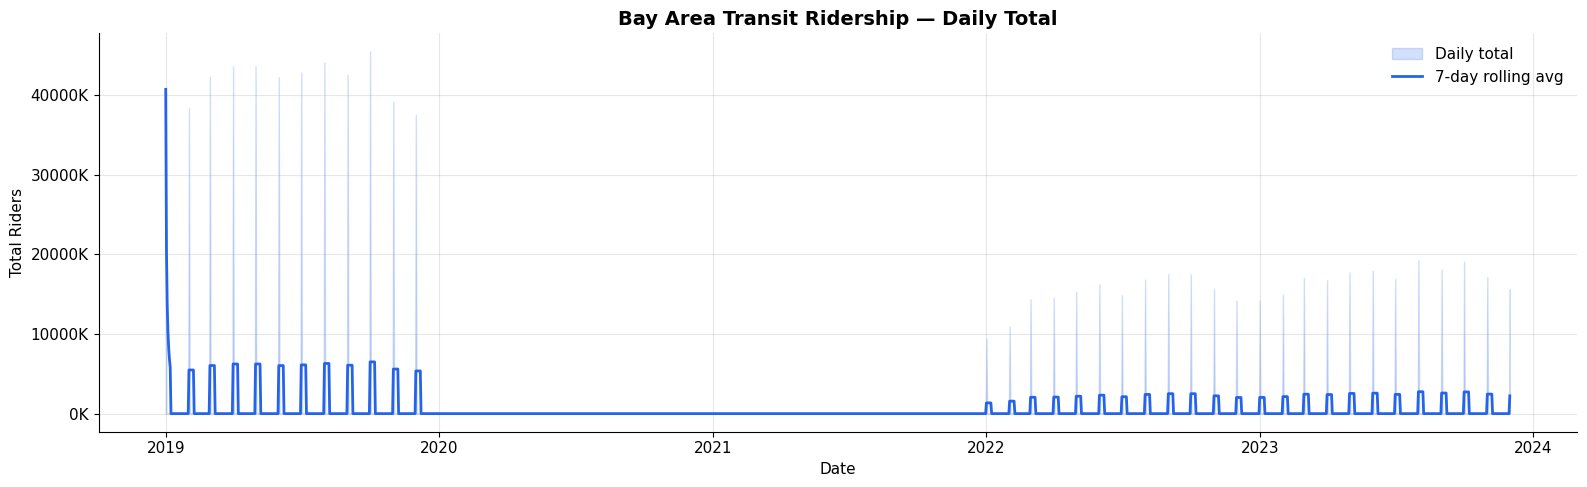

In [4]:
def plot_ridership_overview(df: pd.DataFrame, output_dir: Path) -> None:
    """
    Line plot of total Bay Area ridership over time.
    Annotates major events: COVID drop, Caltrain electrification, Sharks playoffs.
    """
    log.info("Plot 01: Ridership overview …")

    daily = (
        df.groupby(pd.Grouper(key="timestamp", freq="D"))["ridership"]
        .sum()
        .reset_index()
    )
    daily["rolling_7d"] = daily["ridership"].rolling(7, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.fill_between(daily["timestamp"], daily["ridership"],
                    alpha=0.2, color=PALETTE["primary"], label="Daily total")
    ax.plot(daily["timestamp"], daily["rolling_7d"],
            color=PALETTE["primary"], lw=2, label="7-day rolling avg")

    ax.set_title("Bay Area Transit Ridership — Daily Total", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Total Riders")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
    ax.legend(frameon=False)
    fig.tight_layout()
    _save(fig, "01_ridership_overview", output_dir)


# ── Plot 02: Hourly ridership heatmap ──────────────────────────────────────────

plot_ridership_overview(df, PLOTS_DIR)


## Plot 02: Monthly ridership heatmap


2026-05-11 09:26:58,792 [INFO] eda: Plot 02: Monthly seasonality heatmap …
2026-05-11 09:26:59,016 [INFO] eda:   Saved -> eda/plots/02_monthly_heatmap.png


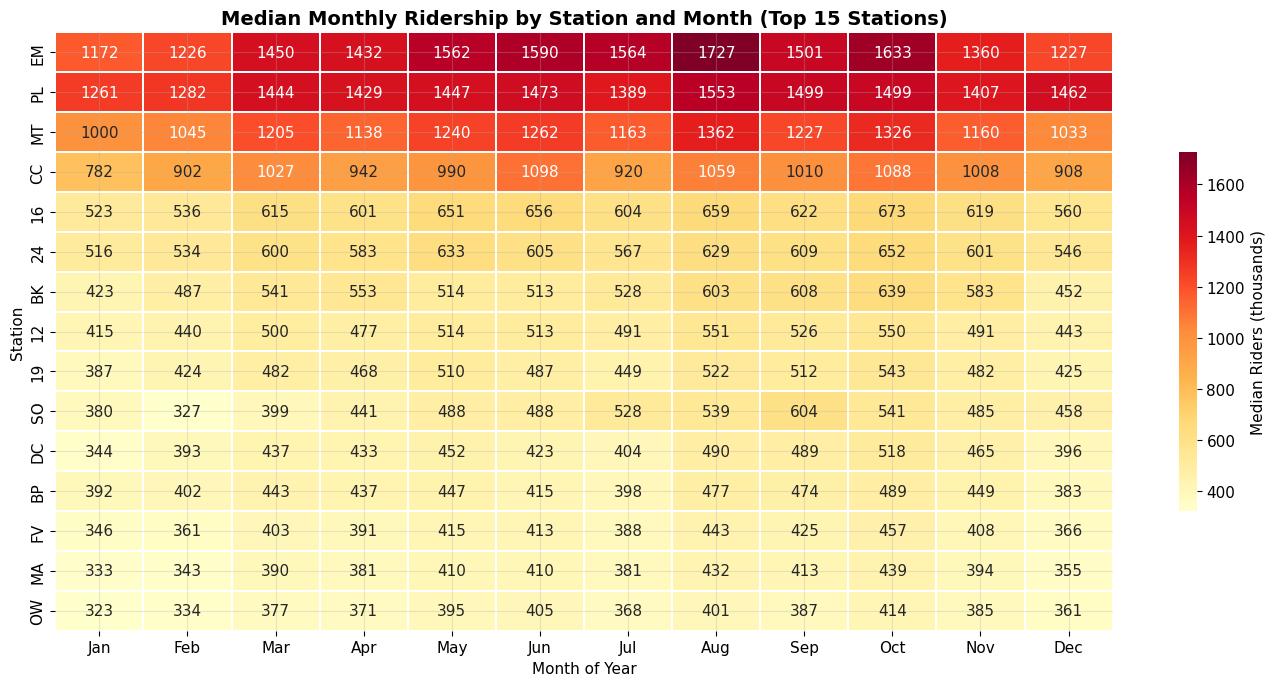

In [5]:
def plot_monthly_heatmap(df: pd.DataFrame, output_dir: Path, top_n: int = 15) -> None:
    """
    Heatmap: rows = stations, columns = month of year.
    Colour = median ridership. Reveals seasonal patterns per station.
    """
    log.info("Plot 02: Monthly seasonality heatmap …")

    top_stations = (
        df.groupby("station_id")["ridership"].median()
        .nlargest(top_n).index.tolist()
    )
    sub = df[df["station_id"].isin(top_stations)].copy()
    sub["month_num"] = sub["timestamp"].dt.month

    pivot = sub.pivot_table(
        values="ridership",
        index="station_id",
        columns="month_num",
        aggfunc="median",
    )
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    import calendar
    col_labels = [calendar.month_abbr[m] for m in pivot.columns]

    fig, ax = plt.subplots(figsize=(14, 7))
    sns.heatmap(
        pivot / 1000,
        cmap="YlOrRd",
        ax=ax,
        linewidths=0.3,
        linecolor="white",
        cbar_kws={"label": "Median Riders (thousands)", "shrink": 0.6},
        fmt=".0f",
        annot=True,
        xticklabels=col_labels,
    )
    ax.set_title(
        f"Median Monthly Ridership by Station and Month (Top {top_n} Stations)",
        fontsize=14, fontweight="bold"
    )
    ax.set_xlabel("Month of Year")
    ax.set_ylabel("Station")
    plt.setp(ax.get_xticklabels(), rotation=0)
    fig.tight_layout()
    _save(fig, "02_monthly_heatmap", output_dir)


plot_monthly_heatmap(df, PLOTS_DIR)


## Plot 03: Day-of-week distribution


2026-05-11 09:26:59,134 [INFO] eda: Plot 03: Day-of-week distribution …
2026-05-11 09:26:59,277 [INFO] eda:   Saved -> eda/plots/03_dow_distribution.png


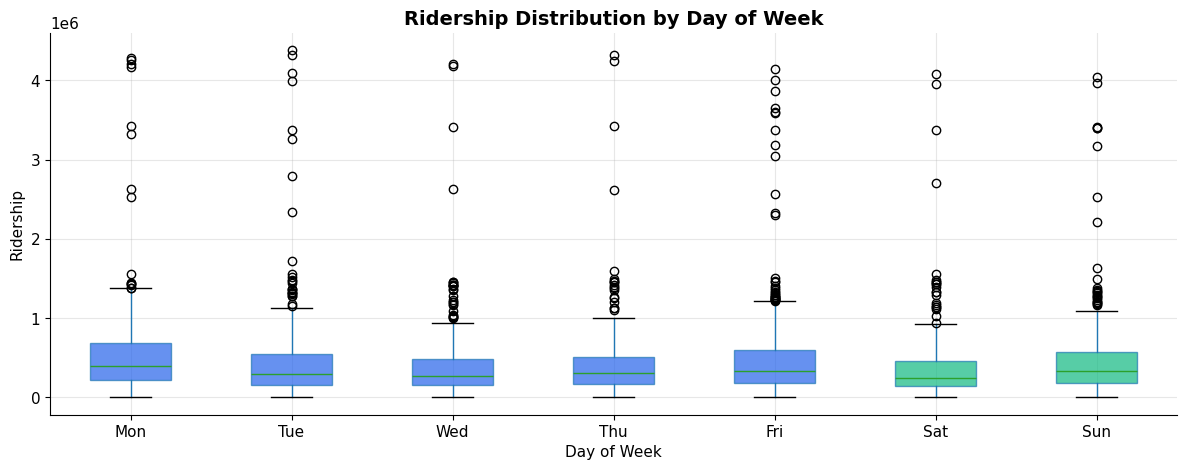

In [6]:
def plot_dow_distribution(df: pd.DataFrame, output_dir: Path) -> None:
    """Box plot of ridership by day of week — shows Mon/Fri anomalies clearly."""
    log.info("Plot 03: Day-of-week distribution …")

    if "day_of_week" not in df.columns:
        df["day_of_week"] = df["timestamp"].dt.dayofweek

    dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    df = df.copy()
    df["dow_name"] = df["day_of_week"].map(dict(enumerate(dow_names)))
    df["dow_name"] = pd.Categorical(df["dow_name"], categories=dow_names, ordered=True)

    fig, ax = plt.subplots(figsize=(12, 5))
    colors = [
        PALETTE["secondary"] if d in ("Sat", "Sun") else PALETTE["primary"]
        for d in dow_names
    ]
    bp = df.boxplot(
        column="ridership",
        by="dow_name",
        ax=ax,
        patch_artist=True,
        return_type="dict",
    )
    for patch, color in zip(bp["ridership"]["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title("Ridership Distribution by Day of Week", fontsize=14, fontweight="bold")
    ax.set_xlabel("Day of Week")
    ax.set_ylabel("Ridership")
    plt.suptitle("")
    fig.tight_layout()
    _save(fig, "03_dow_distribution", output_dir)


# ── Plot 04: Sharks game night spike ──────────────────────────────────────────

plot_dow_distribution(df, PLOTS_DIR)


## Plot 04: Sharks game night spike


2026-05-11 09:26:59,320 [INFO] eda: Plot 04: Sharks game spike …
2026-05-11 09:26:59,428 [INFO] eda:   Saved -> eda/plots/04_sharks_game_spike.png


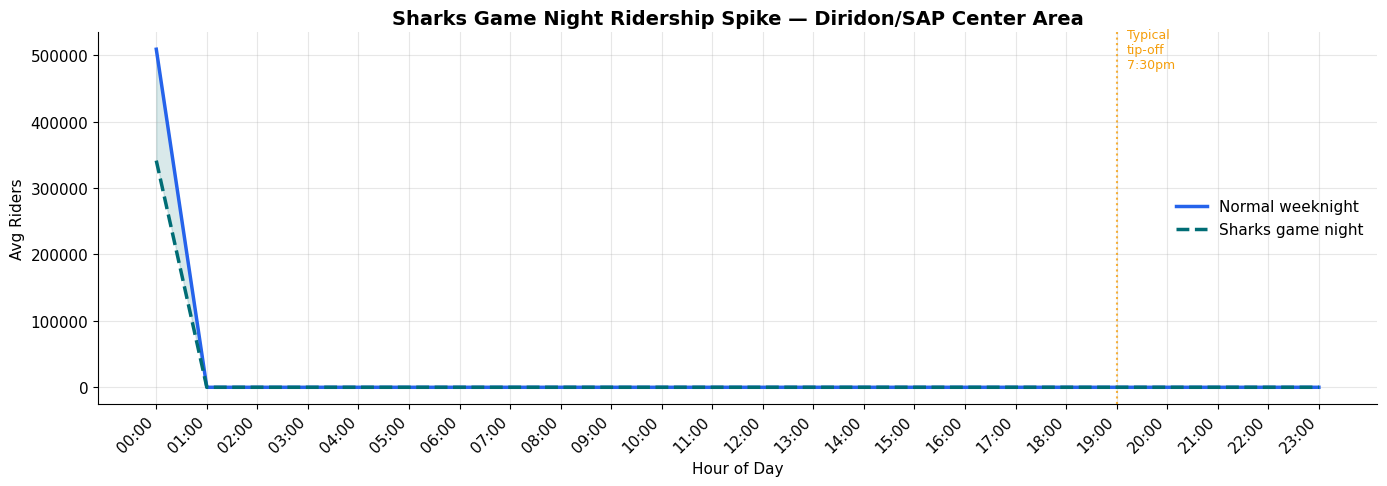

In [7]:
def plot_sharks_game_spike(df: pd.DataFrame, output_dir: Path) -> None:
    """
    Compare average hourly ridership at Diridon-area stations on:
      - Sharks game nights
      - Normal weeknights (same hour, same day-of-week, no game)

    This is THE key visualisation for your project — it shows the signal
    the model is learning from.
    """
    log.info("Plot 04: Sharks game spike …")

    if "is_sharks_game_window" not in df.columns:
        log.warning("  is_sharks_game_window column not found — skipping")
        return

    # Focus on Diridon catchment stations (within 5km of SAP Center)
    if "in_event_catchment" in df.columns:
        local_df = df[df["in_event_catchment"] == True]
    else:
        local_df = df

    if local_df.empty:
        log.warning("  No catchment stations found — using all stations")
        local_df = df

    if "hour_of_day" not in local_df.columns:
        local_df = local_df.copy()
        local_df["hour_of_day"] = local_df["timestamp"].dt.hour

    # Average by hour for game vs non-game weeknights
    game_hourly = (
        local_df[local_df["is_sharks_game_window"] == True]
        .groupby("hour_of_day")["ridership"]
        .mean()
    )
    normal_hourly = (
        local_df[
            (local_df["is_sharks_game_window"] == False) &
            (local_df.get("is_weekend", pd.Series(False, index=local_df.index)) == False)
        ]
        .groupby("hour_of_day")["ridership"]
        .mean()
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    hours = range(24)
    ax.plot(hours, [normal_hourly.get(h, 0) for h in hours],
            color=PALETTE["primary"], lw=2.5, label="Normal weeknight", zorder=2)
    ax.plot(hours, [game_hourly.get(h, 0) for h in hours],
            color=PALETTE["sharks"], lw=2.5, linestyle="--",
            label="Sharks game night", zorder=3)
    ax.fill_between(
        hours,
        [normal_hourly.get(h, 0) for h in hours],
        [game_hourly.get(h, 0) for h in hours],
        alpha=0.15, color=PALETTE["sharks"],
    )

    # Annotate typical tip-off time
    ax.axvline(x=19, color=PALETTE["accent"], linestyle=":", lw=1.5, alpha=0.8)
    ax.text(19.2, ax.get_ylim()[1] * 0.9, "Typical\ntip-off\n7:30pm",
            fontsize=9, color=PALETTE["accent"])

    ax.set_title(
        "Sharks Game Night Ridership Spike — Diridon/SAP Center Area",
        fontsize=14, fontweight="bold"
    )
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Avg Riders")
    ax.set_xticks(range(24))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, ha="right")
    ax.legend(frameon=False)
    fig.tight_layout()
    _save(fig, "04_sharks_game_spike", output_dir)


# ── Plot 05: Rain vs ridership ─────────────────────────────────────────────────

plot_sharks_game_spike(df, PLOTS_DIR)


## Plot 05: Rain vs ridership


2026-05-11 09:26:59,496 [INFO] eda: Plot 05: Rain vs ridership …
2026-05-11 09:26:59,734 [INFO] eda:   Saved -> eda/plots/05_rain_vs_ridership.png


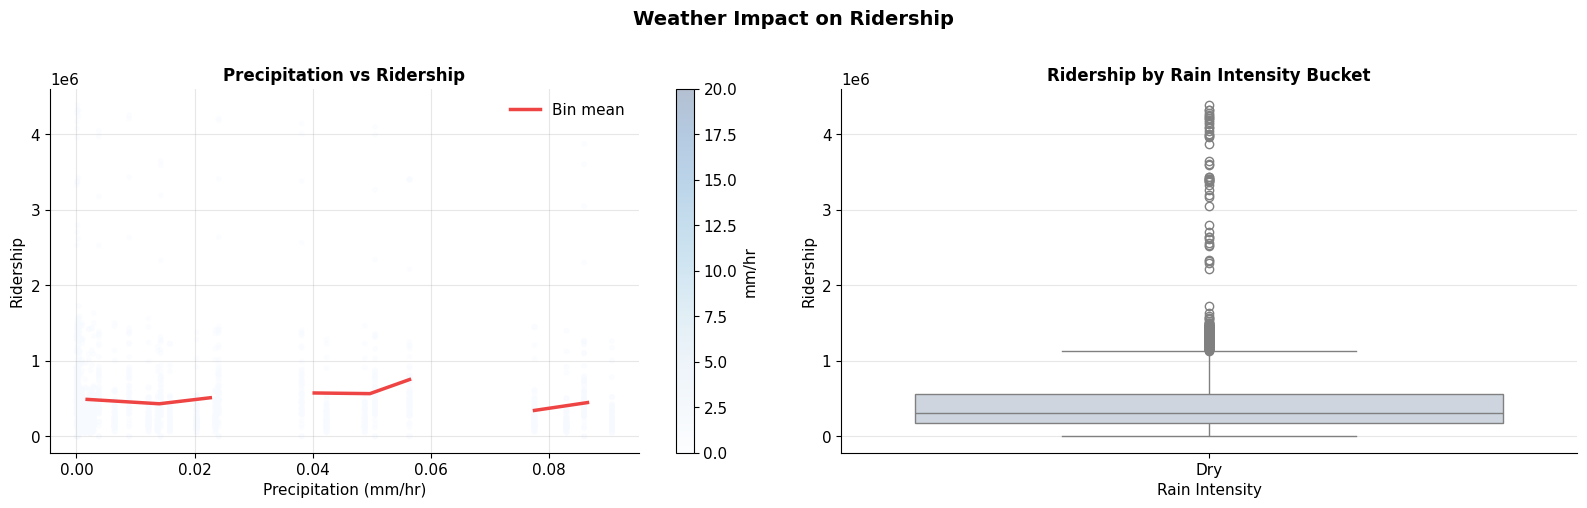

In [8]:
def plot_rain_vs_ridership(df: pd.DataFrame, output_dir: Path) -> None:
    """
    Scatter plot of precipitation vs ridership, coloured by transit mode.
    Reveals the nonlinear relationship: light rain barely matters,
    heavy rain has a large effect.
    """
    log.info("Plot 05: Rain vs ridership …")

    if "precip_mm" not in df.columns:
        log.warning("  precip_mm column not found — skipping")
        return

    sub = df[df["precip_mm"] > 0].sample(min(5000, len(df)), random_state=42)
    if sub.empty:
        log.warning("  No rainy rows found — skipping")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: scatter
    ax = axes[0]
    sc = ax.scatter(
        sub["precip_mm"], sub["ridership"],
        alpha=0.3, s=10, c=sub["precip_mm"],
        cmap="Blues", vmin=0, vmax=20,
    )
    # Bin means to show trend
    sub["precip_bin"] = pd.cut(sub["precip_mm"], bins=10)
    bin_means = sub.groupby("precip_bin")["ridership"].mean()
    bin_centers = sub.groupby("precip_bin")["precip_mm"].mean()
    ax.plot(bin_centers, bin_means, color=PALETTE["danger"], lw=2.5, label="Bin mean")
    ax.set_xlabel("Precipitation (mm/hr)")
    ax.set_ylabel("Ridership")
    ax.set_title("Precipitation vs Ridership", fontsize=12, fontweight="bold")
    ax.legend(frameon=False)
    plt.colorbar(sc, ax=ax, label="mm/hr")

    # Right: box plot by intensity bucket
    ax2 = axes[1]
    if "precip_intensity" in df.columns:
        intensity_labels = {0: "Dry", 1: "Light\n(<2.5mm)", 2: "Moderate\n(2.5-7.6mm)",
                            3: "Heavy\n(7.6-15mm)", 4: "Very Heavy\n(>15mm)"}
        df_plot = df.copy()
        df_plot["intensity_label"] = df_plot["precip_intensity"].map(intensity_labels)
        order = list(intensity_labels.values())
        present = [o for o in order if o in df_plot["intensity_label"].values]
        sns.boxplot(
            data=df_plot, x="intensity_label", y="ridership",
            order=present, ax=ax2,
            palette=["#CBD5E1", "#93C5FD", "#3B82F6", "#1D4ED8", "#1E3A5F"],
        )
        ax2.set_xlabel("Rain Intensity")
        ax2.set_ylabel("Ridership")
        ax2.set_title("Ridership by Rain Intensity Bucket", fontsize=12, fontweight="bold")

    fig.suptitle("Weather Impact on Ridership", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    _save(fig, "05_rain_vs_ridership", output_dir)


# ── Plot 06: Station ridership ranking ─────────────────────────────────────────

plot_rain_vs_ridership(df, PLOTS_DIR)


## Plot 06: Station ridership ranking


2026-05-11 09:26:59,821 [INFO] eda: Plot 06: Station ranking …
2026-05-11 09:26:59,919 [INFO] eda:   Saved -> eda/plots/06_station_ranking.png


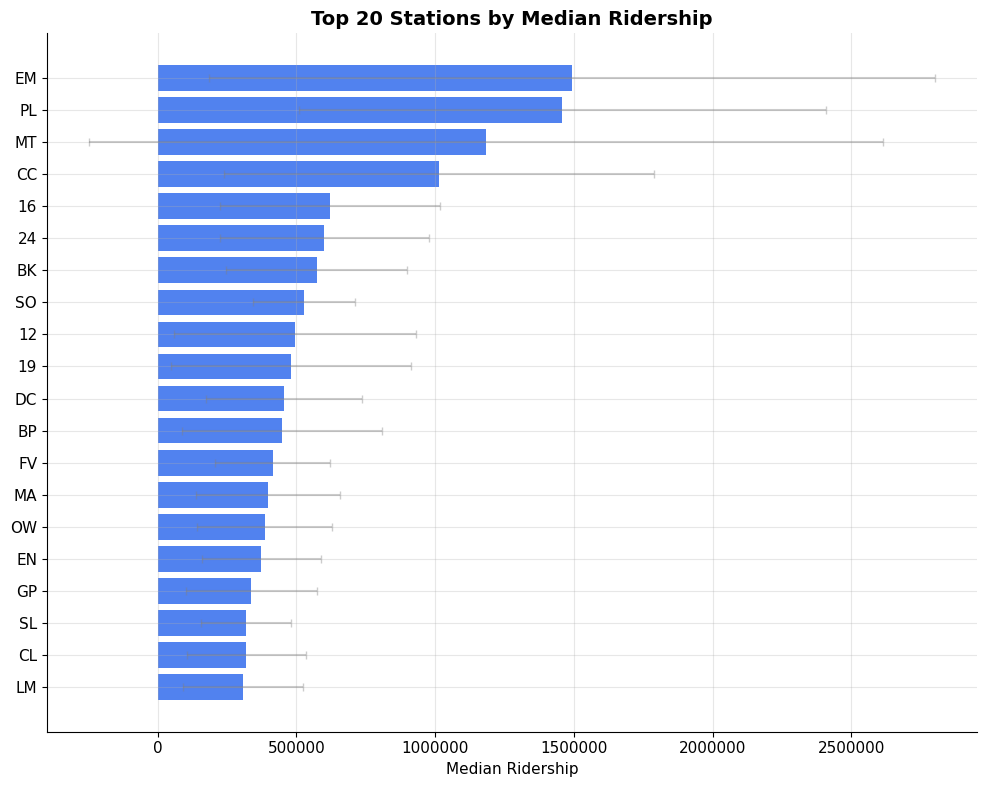

In [9]:
def plot_station_ranking(df: pd.DataFrame, output_dir: Path, top_n: int = 20) -> None:
    """Horizontal bar chart of median ridership per station."""
    log.info("Plot 06: Station ranking …")

    station_stats = (
        df.groupby("station_id")["ridership"]
        .agg(["median", "mean", "std"])
        .sort_values("median", ascending=True)
        .tail(top_n)
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(
        station_stats.index,
        station_stats["median"],
        color=PALETTE["primary"],
        alpha=0.8,
    )
    ax.errorbar(
        station_stats["median"],
        range(len(station_stats)),
        xerr=station_stats["std"],
        fmt="none", color="gray", alpha=0.4, capsize=3,
    )
    ax.set_xlabel("Median Ridership")
    ax.set_title(f"Top {top_n} Stations by Median Ridership", fontsize=14, fontweight="bold")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}"))
    fig.tight_layout()
    _save(fig, "06_station_ranking", output_dir)


# ── Plot 07: Missing data heatmap ──────────────────────────────────────────────

plot_station_ranking(df, PLOTS_DIR)


## Plot 07: Missing data heatmap


In [10]:
def plot_missing_data(df: pd.DataFrame, output_dir: Path) -> None:
    """
    Visual heatmap of which stations have missing ridership data and when.
    White = present, coloured = missing. Reveals API downtime patterns.
    """
    log.info("Plot 07: Missing data heatmap …")

    # Resample to daily presence
    df_copy = df.copy()
    df_copy["date"] = df_copy["timestamp"].dt.date

    pivot = df_copy.pivot_table(
        values="ridership",
        index="station_id",
        columns="date",
        aggfunc="count",
    )
    # Binary: present (1) or missing (0)
    missing_mask = pivot.isna().astype(int)

    # Only show stations with some missing data for clarity
    missing_stations = missing_mask[missing_mask.sum(axis=1) > 0]

    if missing_stations.empty:
        log.info("  No missing data found — great!")
        return

    fig, ax = plt.subplots(figsize=(16, max(4, len(missing_stations) * 0.4)))
    sns.heatmap(
        missing_stations,
        ax=ax,
        cmap=["#E2E8F0", PALETTE["danger"]],
        cbar=False,
        yticklabels=True,
    )
    ax.set_title(
        f"Missing Data Map — {missing_mask.sum(axis=1).sum()} station-days missing",
        fontsize=14, fontweight="bold"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Station")
    # Thin out x-tick labels
    n_ticks = min(20, len(pivot.columns))
    step = max(1, len(pivot.columns) // n_ticks)
    ax.set_xticks(range(0, len(pivot.columns), step))
    ax.set_xticklabels(
        [str(c) for c in pivot.columns[::step]],
        rotation=45, ha="right", fontsize=8,
    )
    fig.tight_layout()
    _save(fig, "07_missing_data", output_dir)


# ── Plot 08: Event proximity vs ridership lift ─────────────────────────────────

plot_missing_data(df, PLOTS_DIR)


2026-05-11 09:26:59,974 [INFO] eda: Plot 07: Missing data heatmap …
2026-05-11 09:26:59,978 [INFO] eda:   No missing data found — great!


## Plot 08: Event proximity vs ridership lift


In [11]:
def plot_event_proximity_lift(df: pd.DataFrame, output_dir: Path) -> None:
    """
    Line plot: event_proximity_score (x) vs mean ridership lift (y).
    Shows how ridership builds up as a game approaches and drops after.
    """
    log.info("Plot 08: Event proximity lift …")

    if "event_proximity_score" not in df.columns or "hours_to_next_event" not in df.columns:
        log.warning("  Event proximity columns not found — skipping")
        return

    # Focus on catchment stations
    if "in_event_catchment" in df.columns:
        local = df[df["in_event_catchment"] == True].copy()
    else:
        local = df.copy()

    if local.empty:
        return

    # Bin hours_to_next_event
    valid = local[local["hours_to_next_event"].between(-2, 6)].copy()
    if valid.empty:
        return

    valid["hours_bin"] = pd.cut(
        valid["hours_to_next_event"],
        bins=np.arange(-2, 6.5, 0.5),
    )
    hourly = valid.groupby("hours_bin")["ridership"].mean()
    bin_centers = valid.groupby("hours_bin")["hours_to_next_event"].mean()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(bin_centers, hourly, color=PALETTE["sharks"], lw=2.5, marker="o", ms=5)
    ax.axvline(x=0, color=PALETTE["accent"], linestyle="--", lw=1.5, alpha=0.8)
    ax.text(0.1, ax.get_ylim()[1] * 0.95, "← Event starts",
            fontsize=9, color=PALETTE["accent"])
    ax.fill_between(bin_centers, hourly, alpha=0.15, color=PALETTE["sharks"])
    ax.set_xlabel("Hours Until Event Start (negative = during/after event)")
    ax.set_ylabel("Mean Ridership")
    ax.set_title(
        "Ridership Lift vs Event Proximity — SAP Center Catchment Stations",
        fontsize=14, fontweight="bold"
    )
    fig.tight_layout()
    _save(fig, "08_event_proximity_lift", output_dir)


# ── Plot 09: Seasonal decomposition ───────────────────────────────────────────

plot_event_proximity_lift(df, PLOTS_DIR)


2026-05-11 09:26:59,984 [INFO] eda: Plot 08: Event proximity lift …


## Plot 09: Seasonal decomposition


In [12]:
def plot_seasonal_decomposition(
    df: pd.DataFrame,
    output_dir: Path,
    station_id: str = None,
) -> None:
    """
    STL decomposition of ridership for one station:
    trend + weekly seasonality + daily seasonality + residual.
    """
    log.info("Plot 09: Seasonal decomposition …")

    try:
        from statsmodels.tsa.seasonal import STL
    except ImportError:
        log.warning("  statsmodels not installed — skipping decomposition")
        return

    # Pick the busiest station if none specified
    if station_id is None:
        station_id = df.groupby("station_id")["ridership"].sum().idxmax()

    station_df = (
        df[df["station_id"] == station_id]
        .sort_values("timestamp")
        .set_index("timestamp")["ridership"]
        .resample("H").mean()
        .interpolate()
    )

    if len(station_df) < 168 * 2:  # need at least 2 weeks
        log.warning(f"  Not enough data for STL on {station_id}")
        return

    stl = STL(station_df, period=24 * 7, robust=True)  # weekly period
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
    components = [
        (station_df,      "Observed",   PALETTE["primary"]),
        (result.trend,    "Trend",      PALETTE["secondary"]),
        (result.seasonal, "Seasonality",PALETTE["accent"]),
        (result.resid,    "Residual",   PALETTE["danger"]),
    ]
    for ax, (series, label, color) in zip(axes, components):
        ax.plot(series.index, series.values, color=color, lw=1.2, alpha=0.85)
        ax.set_ylabel(label, fontsize=10)
        if label == "Residual":
            ax.axhline(0, color="gray", lw=0.8, linestyle="--")

    axes[0].set_title(
        f"STL Decomposition — Station {station_id}",
        fontsize=14, fontweight="bold"
    )
    fig.tight_layout()
    _save(fig, "09_seasonal_decomposition", output_dir)


# ── Plot 10: Correlation heatmap ───────────────────────────────────────────────

plot_seasonal_decomposition(df, PLOTS_DIR)


2026-05-11 09:26:59,990 [INFO] eda: Plot 09: Seasonal decomposition …
2026-05-11 09:26:59,990 [WARNING] eda:   statsmodels not installed — skipping decomposition


## Plot 10: Correlation heatmap


2026-05-11 09:26:59,994 [INFO] eda: Plot 10: Correlation heatmap …
2026-05-11 09:27:00,183 [INFO] eda:   Saved -> eda/plots/10_correlation_heatmap.png


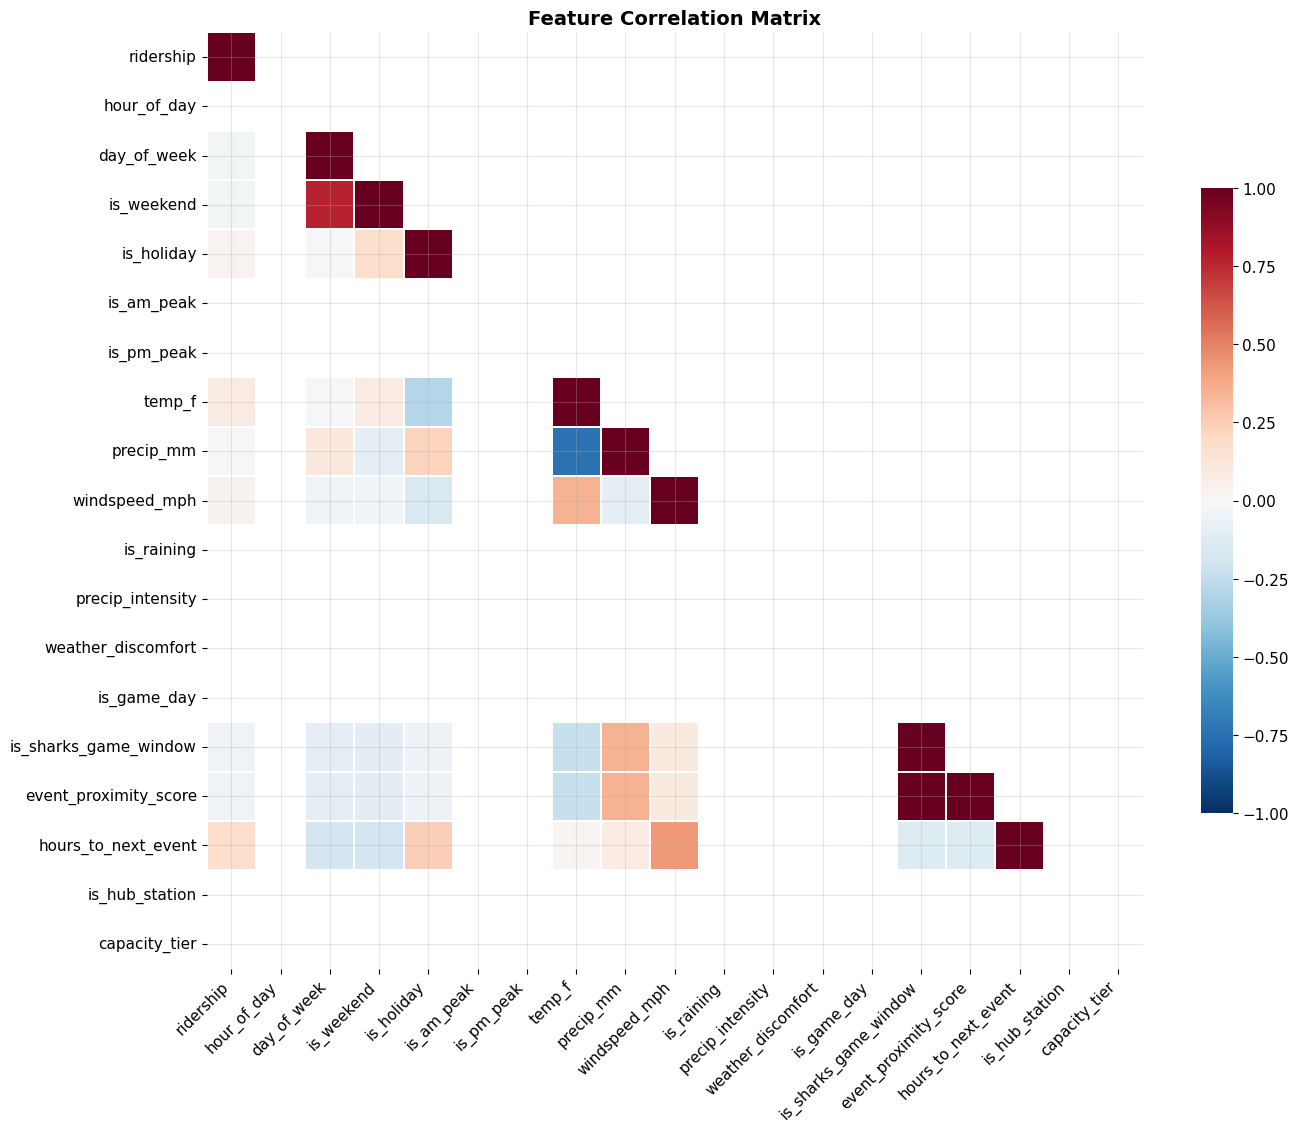

In [13]:
def plot_correlation_heatmap(df: pd.DataFrame, output_dir: Path) -> None:
    """
    Heatmap of Pearson correlations between features and ridership.
    Helps validate that weather + event features carry real signal.
    """
    log.info("Plot 10: Correlation heatmap …")

    feature_cols = [
        "ridership",
        "hour_of_day", "day_of_week", "is_weekend", "is_holiday",
        "is_am_peak", "is_pm_peak",
        "temp_f", "precip_mm", "windspeed_mph", "is_raining",
        "precip_intensity", "weather_discomfort",
        "is_game_day", "is_sharks_game_window", "event_proximity_score",
        "hours_to_next_event", "is_hub_station", "capacity_tier",
        "dist_from_diridon_km", "in_event_catchment",
    ]
    present = [c for c in feature_cols if c in df.columns]
    sub = df[present].dropna()

    if len(sub) < 100:
        log.warning("  Too few rows for correlation heatmap")
        return

    corr = sub.corr()

    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(
        corr,
        mask=mask,
        cmap="RdBu_r",
        center=0,
        vmin=-1, vmax=1,
        annot=len(present) <= 15,
        fmt=".2f",
        square=True,
        linewidths=0.3,
        ax=ax,
        cbar_kws={"shrink": 0.6},
    )
    ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    fig.tight_layout()
    _save(fig, "10_correlation_heatmap", output_dir)


# ── Summary statistics ─────────────────────────────────────────────────────────

plot_correlation_heatmap(df, PLOTS_DIR)
